# Prepare

* Data is available via MLB-StatsAPI as JSON objects. I can use the statsapi schedule end point to get the games I need and then the box scores end point to get the hitting data. This will give one row per team per game. So each game will have two records.
* MLB-StatsAPI is a trusted source for baseball data.
* This data is publicly available.
* I need baseball hitting statistics per team in the 2023 post season, this is exactly what I need.

*Deliverables: A description of all data sources used:*

Using MLB-StatsAPI. Documentation: https://pypi.org/project/MLB-StatsAPI/

In [790]:
##Grabbing postseason offensive metrics for 2023 postseason teams

In [791]:
#!pip install MLB-StatsAPI pandas
import pandas as pd
import numpy as np
from IPython.display import IFrame
import statsapi
import matplotlib.pyplot as plt
import seaborn as sns


In [792]:
all_data = []
team_ids = {
    'ARI': 109,  # Diamondbacks
    'ATL': 144,  # Braves
    'LAD': 119,  # Dodgers
    'PHI': 143,  # Phillies
    'MIL': 158,  # Brewers
    'MIA': 146,  # Marlins
    'BAL': 110,  # Orioles
    'TEX': 140,  # Rangers
    'HOU': 117,  # Astros
    'MIN': 142,  # Twins
    'TBR': 139,  # Rays
    'TOR': 141   # Blue Jays
}
for team_name, team_id in team_ids.items():
    print(f"Fetching postseason data for {team_name}...")
    schedule = statsapi.schedule(
        start_date='2023-10-01',  # postseason start
        end_date='2023-11-02',    # end of World Series
        team=team_id,
    )
    postseason_games_by_team = [game for game in schedule if game['status'] == 'Final' and game['game_type'] != 'R']
    for game in postseason_games_by_team:
            gid = game['game_id']
            box = statsapi.boxscore_data(gid)
            if 'teamInfo' not in box:
                continue
            try:
                team_stats = (
                    box['away']
                    if box['teamInfo']['away']['id'] == team_id
                    else box['home']
                )
                hitting = team_stats['teamStats']['batting']
                all_data.append({
                    'team': team_name,
                    'date': game['game_date'],
                    'game_id': gid,
                    'runs': hitting['runs'],
                    'hits': hitting['hits'],
                    'doubles': hitting['doubles'],
                    'triples': hitting['triples'],
                    'home_runs': hitting['homeRuns'],
                    'strike_outs': hitting['strikeOuts'],
                    'walks': hitting['baseOnBalls'],
                    'stolen_bases': hitting['stolenBases'],
                    'left_on_base': hitting['leftOnBase'],
                    'slug': hitting['slg'],
                    'ops': hitting['ops'],
                    'obp': hitting['obp'],
                    'at_bats': hitting['atBats']
                })
            except KeyError:
                continue
print("Done")
data = pd.DataFrame(all_data)

Fetching postseason data for ARI...
Fetching postseason data for ATL...
Fetching postseason data for LAD...
Fetching postseason data for PHI...
Fetching postseason data for MIL...
Fetching postseason data for MIA...
Fetching postseason data for BAL...
Fetching postseason data for TEX...
Fetching postseason data for HOU...
Fetching postseason data for MIN...
Fetching postseason data for TBR...
Fetching postseason data for TOR...
Done


In [793]:
data.head(-5)

,team,date,game_id,runs,hits,doubles,triples,home_runs,strike_outs,walks,stolen_bases,left_on_base,slug,ops,obp,at_bats
0,ARI,2023-10-03,748582,6,9,1,0,3,10,7,2,22,.559,.949,.390,34
1,ARI,2023-10-04,748578,5,6,1,0,1,11,3,0,7,.439,.768,.329,32
2,ARI,2023-10-07,748555,11,13,4,0,4,9,3,0,9,.744,1.130,.386,39
3,ARI,2023-10-09,748556,4,8,0,0,1,10,5,4,16,.571,.949,.378,31
4,ARI,2023-10-11,748557,4,8,0,0,4,7,3,1,11,.588,.947,.359,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,MIN,2023-10-03,748585,3,5,0,0,2,11,6,0,11,.379,.693,.314,29
73,MIN,2023-10-04,748583,2,7,0,0,0,10,5,1,15,.310,.653,.343,29
74,MIN,2023-10-07,748568,4,9,3,0,2,13,3,0,21,.529,.888,.359,34
75,MIN,2023-10-08,748565,6,10,2,0,1,11,4,0,13,.485,.857,.372,34


# Process

* The dataset being less than 100 rows allowed me to clean the data in google sheets. If it were a bigger dataset I would have uploaded to my BigQuery account, filtered using SQL, and created a new table.
* Yes, the data is correct. Because these are baseball hitting statistics, I could use singles, doubles, triples, home runs, and slug to calculate my at-bats (which I have). If my calculated at-bats matches my actual (with rounding), then the data is accurate. To do this I used a pivot table calculated field shown below.
* For the analysis I would like to do, I would like each row to be a team/game hitting statistics. I have that and given that I have no NaNs, duplicates, and my values are all within a normal range, my data is ready for analysis.
* My cleaning process is documented below in my cleaning log.
  
*Deliverable: Documentation of cleaning process*


## Cleaning Log

* Began with 83 rows, 20 columns. Data types as below.
* Date is type object, changed to type datetime.
* Team is type object, changed to type string.
* OSP, OBP, SLUG are type object, changed to type float. 
* Used data clean-up tools to check for trims, duplicates, and empty values/NaNs, none found.
* Use conditional formatting to check slug, obp nonnegative and less than 1, and ops nonnegative and less than 2.
* To verify singles, doubles, triples, home runs, slug, and at-bats, I used the following formula:
* At-bats = total_bases/slug where total Bases = singles + 2(doubles) + 3(triples) + 4(home_runs) which I verified using a pivot table and a calculated field for at-bats below. 

[GOOGLE SHEETS](https://docs.google.com/spreadsheets/d/e/2PACX-1vTRc0DCmyWNKDvMgDWrD_KrfDgZElxtbI7hXaWd1o2JDoEOxA8PvOUa_B7MbFSuhHYBIV8XQ4iQncrY/pubhtml?gid=1992573443&single=true)


In [794]:
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTRc0DCmyWNKDvMgDWrD_KrfDgZElxtbI7hXaWd1o2JDoEOxA8PvOUa_B7MbFSuhHYBIV8XQ4iQncrY/pubhtml?gid=1992573443&amp;single=true&amp;widget=true&amp;headers=false"
IFrame(src=url, width=900, height=500)

In [795]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   team          82 non-null     object
 1   date          82 non-null     object
 2   game_id       82 non-null     int64 
 3   runs          82 non-null     int64 
 4   hits          82 non-null     int64 
 5   doubles       82 non-null     int64 
 6   triples       82 non-null     int64 
 7   home_runs     82 non-null     int64 
 8   strike_outs   82 non-null     int64 
 9   walks         82 non-null     int64 
 10  stolen_bases  82 non-null     int64 
 11  left_on_base  82 non-null     int64 
 12  slug          82 non-null     object
 13  ops           82 non-null     object
 14  obp           82 non-null     object
 15  at_bats       82 non-null     int64 
dtypes: int64(11), object(5)
memory usage: 10.4+ KB


In [796]:
data['date'] = pd.to_datetime(data['date']) 
data['team'] = data['team'].astype('string')
for feature in ['slug', 'ops','obp']:
    data[feature] = data[feature].astype(float)

In [797]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   team          82 non-null     string        
 1   date          82 non-null     datetime64[ns]
 2   game_id       82 non-null     int64         
 3   runs          82 non-null     int64         
 4   hits          82 non-null     int64         
 5   doubles       82 non-null     int64         
 6   triples       82 non-null     int64         
 7   home_runs     82 non-null     int64         
 8   strike_outs   82 non-null     int64         
 9   walks         82 non-null     int64         
 10  stolen_bases  82 non-null     int64         
 11  left_on_base  82 non-null     int64         
 12  slug          82 non-null     float64       
 13  ops           82 non-null     float64       
 14  obp           82 non-null     float64       
 15  at_bats       82 non-null     int64       

In [798]:
data['extra_base_hits'] = data['doubles'] + data['triples'] + data['home_runs']
data['xbh_rate'] = data['extra_base_hits'] / data['hits'].replace(0, 1)
data['walk_rate'] = data['walks'] / (data['walks'] + data['strike_outs']).replace(0, 1)

In [799]:
data.head(-5)

,team,date,game_id,runs,hits,doubles,triples,home_runs,strike_outs,walks,stolen_bases,left_on_base,slug,ops,obp,at_bats,extra_base_hits,xbh_rate,walk_rate
0,ARI,2023-10-03,748582,6,9,1,0,3,10,7,2,22,0.559,0.949,0.390,34,4,0.444444,0.411765
1,ARI,2023-10-04,748578,5,6,1,0,1,11,3,0,7,0.439,0.768,0.329,32,2,0.333333,0.214286
2,ARI,2023-10-07,748555,11,13,4,0,4,9,3,0,9,0.744,1.130,0.386,39,8,0.615385,0.250000
3,ARI,2023-10-09,748556,4,8,0,0,1,10,5,4,16,0.571,0.949,0.378,31,1,0.125000,0.333333
4,ARI,2023-10-11,748557,4,8,0,0,4,7,3,1,11,0.588,0.947,0.359,32,4,0.500000,0.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,MIN,2023-10-03,748585,3,5,0,0,2,11,6,0,11,0.379,0.693,0.314,29,2,0.400000,0.352941
73,MIN,2023-10-04,748583,2,7,0,0,0,10,5,1,15,0.310,0.653,0.343,29,0,0.000000,0.333333
74,MIN,2023-10-07,748568,4,9,3,0,2,13,3,0,21,0.529,0.888,0.359,34,5,0.555556,0.187500
75,MIN,2023-10-08,748565,6,10,2,0,1,11,4,0,13,0.485,0.857,0.372,34,3,0.300000,0.266667


In [800]:
grouped_runs_by_game = data.groupby(['game_id','team'])['runs'].first()

In [801]:
grouped_runs_by_game.head(10)

game_id  team
748534   ARI      0
         TEX      5
748535   ARI      7
         TEX     11
748537   ARI      4
         PHI      2
748538   ARI      1
         PHI      6
748539   ARI      5
         PHI      1
Name: runs, dtype: int64

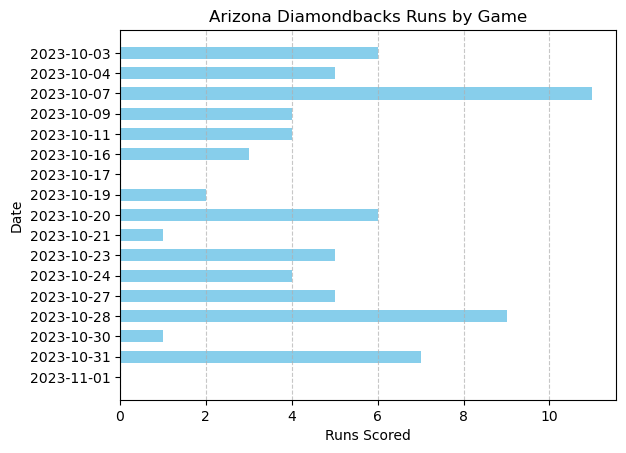

In [802]:
# Lets get the data where team is 'ARI', we'll plot runs by game. I will change date to string for this and change it back. 

data_ari = data[data['team'] == 'ARI'].sort_values(by = 'date', ascending = False)


plt.barh(data_ari['date'].astype(str),data_ari['runs'] , color='skyblue', height=0.6)
plt.title("Arizona Diamondbacks Runs by Game")
plt.xlabel("Runs Scored")  
plt.ylabel("Date")     
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [803]:
data['date'] = pd.to_datetime(data['date']) 
data_ari['date'] = pd.to_datetime(data_ari['date']) 

In [804]:
data_ari.head()

,team,date,game_id,runs,hits,doubles,triples,home_runs,strike_outs,walks,stolen_bases,left_on_base,slug,ops,obp,at_bats,extra_base_hits,xbh_rate,walk_rate
16,ARI,2023-11-01,748534,0,5,1,0,0,10,6,2,19,0.391,0.719,0.328,31,1,0.200,0.375000
15,ARI,2023-10-31,748535,7,12,2,0,1,6,3,0,16,0.434,0.769,0.335,35,3,0.250,0.333333
14,ARI,2023-10-30,748540,1,6,3,0,0,9,2,0,9,0.417,0.739,0.322,30,3,0.500,0.181818
13,ARI,2023-10-28,748541,9,16,3,0,1,2,4,1,15,0.462,0.811,0.349,37,4,0.250,0.666667
12,ARI,2023-10-27,748542,5,8,1,1,1,14,1,4,9,0.341,0.555,0.214,41,3,0.375,0.066667


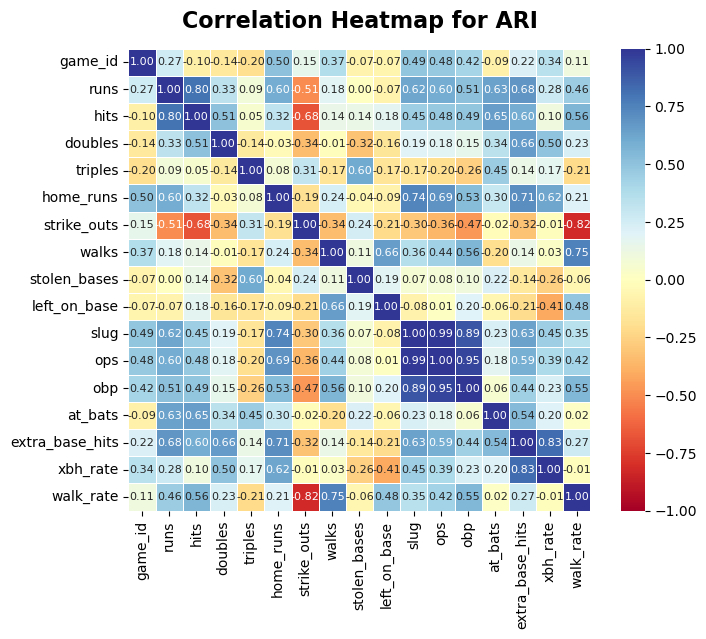

In [805]:
corr_matrix = data_ari.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, 
    annot_kws={"size": 8},
    fmt=".2f",  
    cmap="RdYlBu",
    vmin=-1,  
    vmax=1,  
    linewidths=0.5, 
    square=True, 
)
# 5. Display the plot
plt.title("Correlation Heatmap for ARI", fontsize=16, fontweight="bold", pad=15)
plt.show()

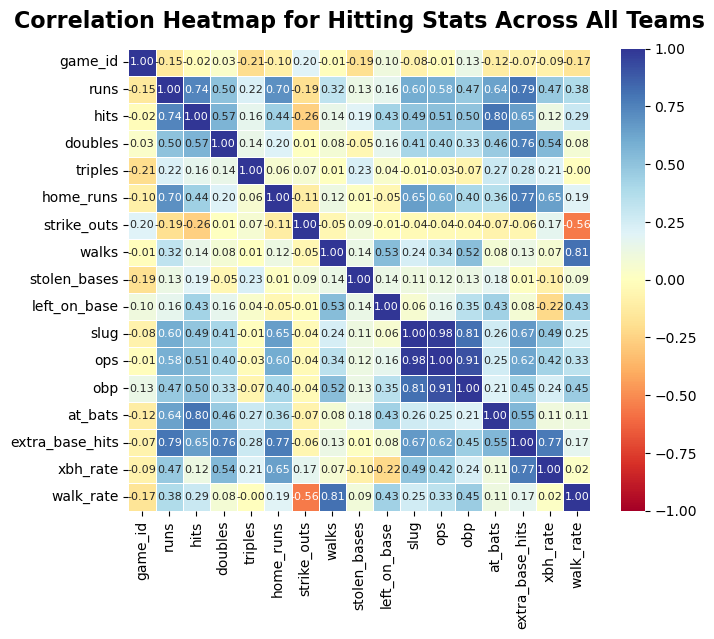

In [806]:
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, 
    annot_kws={"size": 8},
    fmt=".2f",  
    cmap="RdYlBu",
    vmin=-1,  
    vmax=1,  
    linewidths=0.5, 
    square=True, 
)
# 5. Display the plot
plt.title("Correlation Heatmap for Hitting Stats Across All Teams", fontsize=16, fontweight="bold", pad=15)
plt.show()

[Tableau Viz](https://public.tableau.com/views/2023MLBPostseasonOffenseDashboard/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

In [807]:
%%html
<div class='tableauPlaceholder' id='viz1789021233791' style='position: relative'><noscript><a href='#'><img alt='Dashboard 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;D4&#47;D47XXHQRR&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='path' value='shared&#47;D47XXHQRR' /> <param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;D4&#47;D47XXHQRR&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1789021233791');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';} else { vizElement.style.width='100%';vizElement.style.height='1127px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

# Share

* For all teams there is a strong correlation between runs and extra base hits, at-bats, ops, and obp.
* Texas had the most left on base and the most runs scored with a lob:runs rato of 260:97.
* Arizona had the second most left on base and the second most runs scored with a lob:runs ratio of 237:73
* I visualized scoring percentage as the proportion of runs to runs and left on base. I plotted trend lines across post-season dates. The only team that had a meaningful positive slope was the Texas Rangers.
* Visualizing scoring rate as a heat map across games showed that besides Texas, Philadelphia had the second most number of very high scoring rate games. However, they also had some very bad scoring rate games. It appears that when Philadelphia was hot they were very hot, but when they weren't hot they were poor. Arizona had a more consistent scoring philosphy in comparison. I calculated the percentage of home runs to hits for each team across all games.
* Successful teams were willing to leave players on base as a price for scoring runs. Howeover, the most successful teams had a higher scoring percentage (converting on-base to runs). Teams that were successful hit for extra bases, however teams like Philadelphia that exploded for a game or two did not do well in the course of their post season. Teams like Texas and Arizona that did not have as high of high scoring percentage games, had more games that had above average scoring percentage games.
* These findings reveal that a hitting approach that emphasizes extra base hits is important, but consistency is also important. Perphaps a more balanced approach over swinging for the fences.

  

*Deliverables : Visualization in Tableau*

In [808]:
data.head(5)

,team,date,game_id,runs,hits,doubles,triples,home_runs,strike_outs,walks,stolen_bases,left_on_base,slug,ops,obp,at_bats,extra_base_hits,xbh_rate,walk_rate
0,ARI,2023-10-03,748582,6,9,1,0,3,10,7,2,22,0.559,0.949,0.390,34,4,0.444444,0.411765
1,ARI,2023-10-04,748578,5,6,1,0,1,11,3,0,7,0.439,0.768,0.329,32,2,0.333333,0.214286
2,ARI,2023-10-07,748555,11,13,4,0,4,9,3,0,9,0.744,1.130,0.386,39,8,0.615385,0.250000
3,ARI,2023-10-09,748556,4,8,0,0,1,10,5,4,16,0.571,0.949,0.378,31,1,0.125000,0.333333
4,ARI,2023-10-11,748557,4,8,0,0,4,7,3,1,11,0.588,0.947,0.359,32,4,0.500000,0.300000


In [809]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.impute import SimpleImputer


In [810]:
#Seperate target from predictors
y = data.runs
X = data.drop(['runs','hits','date'], axis = 1)
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X,y, train_size = .8, test_size = .2, random_state = 0)
"""
This is overkill to highlight pipeline preprocessing knowledge. You could easily apply get_dummies and not impute any values
as wouldn't make much sense in this case. 
"""
categorical_cols  = [col for col in X.columns if X[col].dtype == 'object']
numerical_cols = [col for col in X.columns if X[col].dtype in ['int64', 'float64'] ]
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
#one-hot categorical columns, scale numerical columns.
categorical_transformer = Pipeline(steps = [
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])
numerical_transformer = Pipeline(steps = [
    ('scale', StandardScaler())
])
preprocessor = ColumnTransformer(transformers = [
    ('categorical', categorical_transformer, categorical_cols),
    ('numerical', numerical_transformer, numerical_cols)
])
# Define my model 
my_model = RandomForestRegressor(n_estimators = 100, random_state = 0)
#Bundle preprocessing and model
my_pipeline = Pipeline(steps = [
    ('preprocessing', preprocessor),
    ('model', my_model)
])                        
# fit model
my_pipeline.fit(X_train, y_train)
pred = my_pipeline.predict(X_valid)
score = root_mean_squared_error(pred, y_valid)
print('RMSE:', score)


RMSE: 1.3760664313649293


In [811]:
data_comp = data.copy()
data_comp.insert(3, 'predicted_runs', my_pipeline.predict(X))
data_comp.insert(4,'difference_runs', data_comp["runs"] - data_comp["predicted_runs"] )
data_comp.head(5)

,team,date,game_id,predicted_runs,difference_runs,runs,hits,doubles,triples,home_runs,...,walks,stolen_bases,left_on_base,slug,ops,obp,at_bats,extra_base_hits,xbh_rate,walk_rate
0,ARI,2023-10-03,748582,5.87,0.13,6,9,1,0,3,...,7,2,22,0.559,0.949,0.390,34,4,0.444444,0.411765
1,ARI,2023-10-04,748578,4.20,0.80,5,6,1,0,1,...,3,0,7,0.439,0.768,0.329,32,2,0.333333,0.214286
2,ARI,2023-10-07,748555,9.24,1.76,11,13,4,0,4,...,3,0,9,0.744,1.130,0.386,39,8,0.615385,0.250000
3,ARI,2023-10-09,748556,3.89,0.11,4,8,0,0,1,...,5,4,16,0.571,0.949,0.378,31,1,0.125000,0.333333
4,ARI,2023-10-11,748557,4.48,-0.48,4,8,0,0,4,...,3,1,11,0.588,0.947,0.359,32,4,0.500000,0.300000


In [812]:
team_run_difference = data_comp.groupby(['team'])['difference_runs'].mean().sort_values()
team_run_difference

team
MIN   -0.388333
MIL   -0.310000
BAL   -0.283333
TOR   -0.255000
MIA   -0.220000
ATL   -0.205000
HOU   -0.135455
TBR   -0.095000
PHI    0.000769
TEX    0.082353
ARI    0.334118
LAD    0.413333
Name: difference_runs, dtype: float64

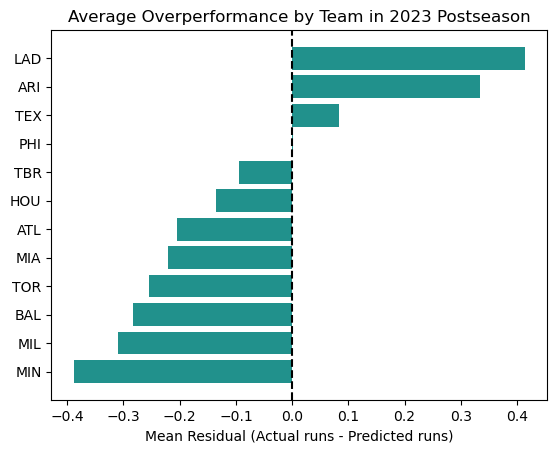

In [813]:
import matplotlib.pyplot as plt
colors = plt.cm.viridis([0.5]) 
plt.barh(team_run_difference.index, team_run_difference.values, color = colors)
plt.title("Average Overperformance by Team in 2023 Postseason")
plt.xlabel("Mean Residual (Actual runs - Predicted runs)")
plt.axvline(0, color="black", linestyle="--")
plt.show()

### Extract Weights 

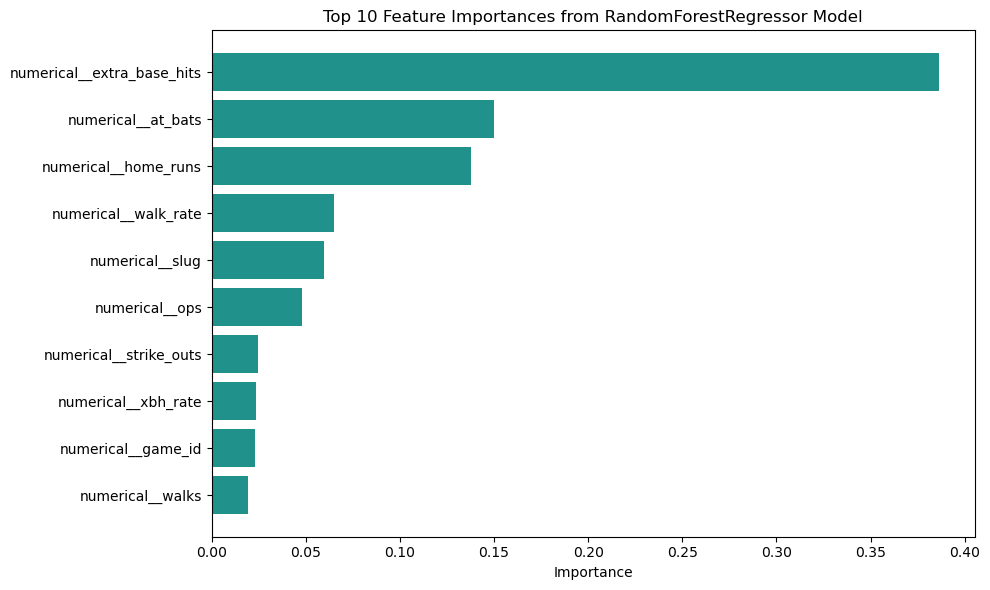

In [814]:
feature_names = my_pipeline.named_steps['preprocessing'].get_feature_names_out()
coefficients = my_pipeline.named_steps['model'].feature_importances_
feature_importance = pd.DataFrame({'feature': feature_names,'importance': coefficients})
top_10 = feature_importance.head().sort_values(by = "importance")
colors = plt.cm.viridis([0.5]) 
plt.figure(figsize=(10,6))
plt.barh(top10['feature'], top10['importance'], color = colors)
plt.title("Top 10 Feature Importances from RandomForestRegressor Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

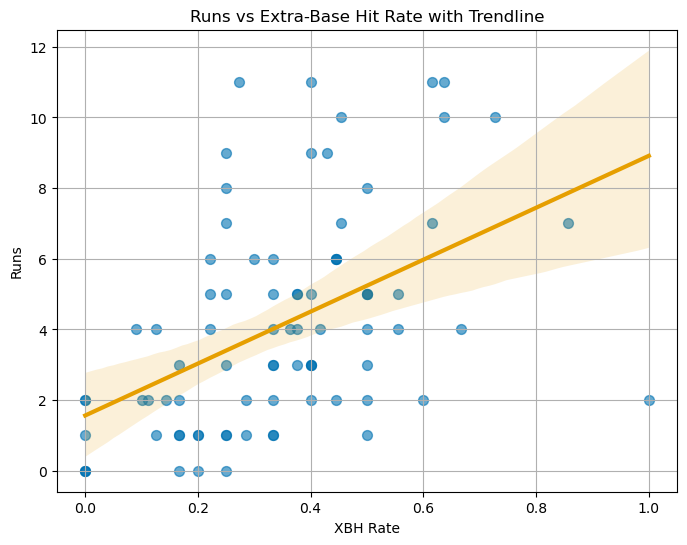

In [815]:

plt.figure(figsize=(8,6))
sns.regplot(x='xbh_rate', y='runs', data=data, scatter_kws={'color': '#0072B2', 'alpha': 0.6, 's': 50}, line_kws={'color': '#E69F00', 'lw': 3} )
plt.xlabel("XBH Rate")
plt.ylabel("Runs")
plt.title("Runs vs Extra-Base Hit Rate with Trendline")
plt.grid(True)
plt.show()


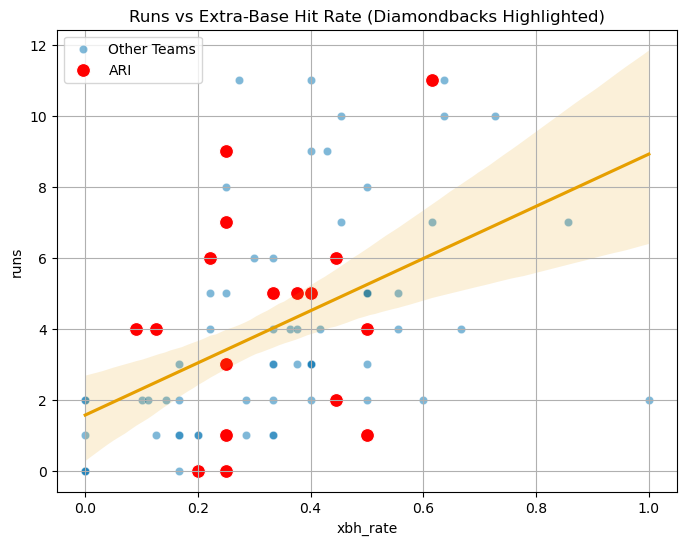

In [816]:

plt.figure(figsize=(8,6))
sns.scatterplot(x='xbh_rate', y='runs', data=data, alpha=0.5, color = '#0072B2', label='Other Teams')
sns.scatterplot(x='xbh_rate', y='runs', data=data[data['team']=='ARI'], color='red', s=100, label='ARI')
sns.regplot(x='xbh_rate', y='runs', data=data, scatter=False, color='#E69F00')
plt.xlabel("xbh_rate")
plt.ylabel("runs")
plt.title("Runs vs Extra-Base Hit Rate (Diamondbacks Highlighted)")
plt.legend()
plt.grid(True)
plt.show()

### Validating Model on 2025 PostSeason Hitting Statistics 

In [817]:
# I refactored the data-fetching into a python module got postseason.py. Using that here to fetch 2025

from postseason import get_postseason_hitting_by_year
df_25 = get_postseason_hitting_by_year(2025)
df_25.head()

,team,game_id,runs,hits,doubles,triples,home_runs,strike_outs,walks,stolen_bases,left_on_base,slug,ops,obp,at_bats,extra_base_hits,xbh_rate,walk_rate
0,BOS,813074,3,8,3,0,0,8,6,1,15,.324,.674,.350,34,3,0.375000,0.428571
1,BOS,813070,3,6,0,0,1,9,3,0,16,.313,.637,.324,30,1,0.166667,0.250000
2,BOS,813065,0,5,0,0,0,13,1,0,14,.260,.540,.280,32,0,0.000000,0.071429
3,CHC,813066,3,6,0,0,2,13,1,0,6,.444,.685,.241,27,2,0.333333,0.071429
4,CHC,813064,0,4,1,0,0,11,1,0,9,.298,.511,.213,30,1,0.250000,0.083333


In [818]:
y_25 = df_25.runs
X_25 = df_25.drop(['runs','hits'], axis = 1)
X_25.head()

,team,game_id,doubles,triples,home_runs,strike_outs,walks,stolen_bases,left_on_base,slug,ops,obp,at_bats,extra_base_hits,xbh_rate,walk_rate
0,BOS,813074,3,0,0,8,6,1,15,.324,.674,.350,34,3,0.375000,0.428571
1,BOS,813070,0,0,1,9,3,0,16,.313,.637,.324,30,1,0.166667,0.250000
2,BOS,813065,0,0,0,13,1,0,14,.260,.540,.280,32,0,0.000000,0.071429
3,CHC,813066,0,0,2,13,1,0,6,.444,.685,.241,27,2,0.333333,0.071429
4,CHC,813064,1,0,0,11,1,0,9,.298,.511,.213,30,1,0.250000,0.083333


In [819]:
pred2 = my_pipeline.predict(X_25)
score2 = root_mean_squared_error(y_25, pred2)
print('RMSE:', score2)


RMSE: 1.727524671129678


Lets see if this margin of error is enought to predict game outcomes accurately. 

In [820]:
df_25_v1 = df_25.copy()
df_25_v1.insert(3,'predicted_runs',pred2)
difference_of_runs = df_25_v1['runs'] - df_25_v1['predicted_runs']
df_25_v1.insert(4,'difference_runs',difference_of_runs)

In [821]:
df_25_v1.head()

,team,game_id,runs,predicted_runs,difference_runs,hits,doubles,triples,home_runs,strike_outs,walks,stolen_bases,left_on_base,slug,ops,obp,at_bats,extra_base_hits,xbh_rate,walk_rate
0,BOS,813074,3,4.22,-1.22,8,3,0,0,8,6,1,15,.324,.674,.350,34,3,0.375000,0.428571
1,BOS,813070,3,2.41,0.59,6,0,0,1,9,3,0,16,.313,.637,.324,30,1,0.166667,0.250000
2,BOS,813065,0,1.11,-1.11,5,0,0,0,13,1,0,14,.260,.540,.280,32,0,0.000000,0.071429
3,CHC,813066,3,3.84,-0.84,6,0,0,2,13,1,0,6,.444,.685,.241,27,2,0.333333,0.071429
4,CHC,813064,0,1.22,-1.22,4,1,0,0,11,1,0,9,.298,.511,.213,30,1,0.250000,0.083333


In [822]:
df_25_v1['team_idx'] = df_25_v1.groupby('game_id').cumcount() +1

In [823]:
df_25_v1[df_25_v1['game_id'] == 813074]

,team,game_id,runs,predicted_runs,difference_runs,hits,doubles,triples,home_runs,strike_outs,...,stolen_bases,left_on_base,slug,ops,obp,at_bats,extra_base_hits,xbh_rate,walk_rate,team_idx
0,BOS,813074,3,4.22,-1.22,8,3,0,0,8,...,1,15,.324,.674,.350,34,3,0.375000,0.428571,1
50,NYY,813074,1,2.04,-1.04,7,0,0,1,13,...,0,15,.303,.515,.212,33,1,0.142857,0.000000,2


In [824]:
df_25_pivot = df_25_v1.pivot(index='game_id', columns='team_idx')
df_25_pivot.head()

team      runs    predicted_runs       difference_runs       hits  \
team_idx    1    2    1  2              1     2               1     2    1   
game_id                                                                      
813022    LAD  TOR    1  6           2.60  5.89           -1.60  0.11    4   
813023    LAD  TOR    2  6           1.40  4.31            0.60  1.69    6   
813024    LAD  TOR    5  4           7.61  5.04           -2.61 -1.04   11   
813025    LAD  TOR    3  1           2.19  2.31            0.81 -1.31    4   
813026    LAD  TOR    5  1           4.22  1.61            0.78 -0.61    6   

              ...   obp       at_bats     extra_base_hits     xbh_rate  \
team_idx   2  ...     1     2       1   2               1  2         1   
game_id       ...                                                        
813022     9  ...  .296  .341      30  33               1  3  0.250000   
813023    11  ...  .315  .333      31  38               1  2  0.166667   
813024    14  ...  .294  .347      41  43               4  4  0.363636   
813025     8  ...  .287  .336      31  33               3  4  0.750000   
813026     4  ...  .284  .333      33  30               3  1  0.500000   

                   walk_rate            
team_idx         2         1         2  
game_id                                 
813022    0.333333  0.062500  0.461538  
813023    0.181818  0.363636  0.250000  
813024    0.285714  0.500000  0.250000  
813025    0.500000  0.250000  0.200000  
813026    0.250000  0.300000  0.000000  

[5 rows x 38 columns]

In [825]:
df_25_pivot.columns

MultiIndex([(           'team', 1),
            (           'team', 2),
            (           'runs', 1),
            (           'runs', 2),
            ( 'predicted_runs', 1),
            ( 'predicted_runs', 2),
            ('difference_runs', 1),
            ('difference_runs', 2),
            (           'hits', 1),
            (           'hits', 2),
            (        'doubles', 1),
            (        'doubles', 2),
            (        'triples', 1),
            (        'triples', 2),
            (      'home_runs', 1),
            (      'home_runs', 2),
            (    'strike_outs', 1),
            (    'strike_outs', 2),
            (          'walks', 1),
            (          'walks', 2),
            (   'stolen_bases', 1),
            (   'stolen_bases', 2),
            (   'left_on_base', 1),
            (   'left_on_base', 2),
            (           'slug', 1),
            (           'slug', 2),
            (            'ops', 1),
            (            'op

In [826]:
df_25_pivot.columns = [f"{feature}_{idx}" for feature, idx in df_25_pivot.columns]
combined25_df = df_25_pivot.reset_index()

In [827]:
combined25_df.head()

,game_id,team_1,team_2,runs_1,runs_2,predicted_runs_1,predicted_runs_2,difference_runs_1,difference_runs_2,hits_1,...,obp_1,obp_2,at_bats_1,at_bats_2,extra_base_hits_1,extra_base_hits_2,xbh_rate_1,xbh_rate_2,walk_rate_1,walk_rate_2
0,813022,LAD,TOR,1,6,2.60,5.89,-1.60,0.11,4,...,.296,.341,30,33,1,3,0.250000,0.333333,0.062500,0.461538
1,813023,LAD,TOR,2,6,1.40,4.31,0.60,1.69,6,...,.315,.333,31,38,1,2,0.166667,0.181818,0.363636,0.250000
2,813024,LAD,TOR,5,4,7.61,5.04,-2.61,-1.04,11,...,.294,.347,41,43,4,4,0.363636,0.285714,0.500000,0.250000
3,813025,LAD,TOR,3,1,2.19,2.31,0.81,-1.31,4,...,.287,.336,31,33,3,4,0.750000,0.500000,0.250000,0.200000
4,813026,LAD,TOR,5,1,4.22,1.61,0.78,-0.61,6,...,.284,.333,33,30,3,1,0.500000,0.250000,0.300000,0.000000


In [828]:
combined25_df['actual_winner'] = combined25_df.apply(lambda row: row['team_1'] if row['runs_1'] > row['runs_2'] else row['team_2'], axis = 1)
combined25_df['predicted_winner'] = combined25_df.apply(lambda row: row['team_1'] 
                                                        if row['predicted_runs_1'] > row['predicted_runs_2'] 
                                                        else row['team_2'], axis = 1
                                                       )

In [829]:
number_of_correct_matchups = (combined25_df['actual_winner'] == combined25_df['predicted_winner']).sum()
total_games = len(combined25_df)
print("Number of correct predictions: {}, Total Accuracy: {:.2%}".format(number_of_correct_matchups, number_of_correct_matchups/total_games ))


Number of correct predictions: 41, Total Accuracy: 87.23%


In [830]:
combined25_df

,game_id,team_1,team_2,runs_1,runs_2,predicted_runs_1,predicted_runs_2,difference_runs_1,difference_runs_2,hits_1,...,at_bats_1,at_bats_2,extra_base_hits_1,extra_base_hits_2,xbh_rate_1,xbh_rate_2,walk_rate_1,walk_rate_2,actual_winner,predicted_winner
0,813022,LAD,TOR,1,6,2.60,5.89,-1.60,0.11,4,...,30,33,1,3,0.250000,0.333333,0.062500,0.461538,TOR,TOR
1,813023,LAD,TOR,2,6,1.40,4.31,0.60,1.69,6,...,31,38,1,2,0.166667,0.181818,0.363636,0.250000,TOR,TOR
2,813024,LAD,TOR,5,4,7.61,5.04,-2.61,-1.04,11,...,41,43,4,4,0.363636,0.285714,0.500000,0.250000,LAD,LAD
3,813025,LAD,TOR,3,1,2.19,2.31,0.81,-1.31,4,...,31,33,3,4,0.750000,0.500000,0.250000,0.200000,LAD,TOR
4,813026,LAD,TOR,5,1,4.22,1.61,0.78,-0.61,6,...,33,30,3,1,0.500000,0.250000,0.300000,0.000000,LAD,LAD
5,813027,LAD,TOR,4,11,2.07,7.30,1.93,3.70,6,...,32,35,1,3,0.166667,0.214286,0.315789,0.500000,TOR,TOR
6,813031,LAD,MIL,5,1,4.41,1.12,0.59,-0.12,9,...,33,30,3,2,0.333333,0.400000,0.166667,0.266667,LAD,LAD
7,813032,LAD,TOR,6,5,8.74,4.27,-2.74,0.73,16,...,63,67,7,2,0.437500,0.133333,0.434783,0.360000,LAD,LAD
8,813033,LAD,MIL,3,1,2.24,1.12,0.76,-0.12,5,...,29,31,2,2,0.400000,0.500000,0.166667,0.200000,LAD,LAD
9,813034,LAD,MIL,5,1,7.49,1.75,-2.49,-0.75,11,...,35,31,6,1,0.545455,0.333333,0.333333,0.125000,LAD,LAD


# Summarize

* I trained a regression model where my target variable was runs. My model type was a random forest regressor. My loss function was mean squared error (the default option for this model). It's important to note that optimizing this model on mse is the same as optimizing via rmse. So it makes sense to evaulate my model based on RMSE like I did here. I chose to use mean squared error as the loss function beacuse runs are usually small nonnegative integers less than 15. For this reason, it's imperative to be accurate so we must penalize outlying predictions, and MSE does that.My RMSE was about 1.38. I validated my model on 2025 postseason data and scored a slightly higher RMSE of 1.73.

* **The most important feature in predicting runs was extra base hits, and by a large margin.** That was a correlation that I saw in the data visualzation so I am not surprised, **but now we have quantified this importance**.  To my surpise, the second most important feature was not home runs, it was at-bats. This is something we started to see in the Tableau scoring percentage heatmap. This gives evidence to the theory that hitting for extra bases more consistenly in a more disciplined way is a good approach for runs. It's also important to note that both teams that made it to the world series outpreformed their predicted runs (on average). 
* For fun, I decided to compare predicted winners versus actual winners. To my surprise, the model was incredibly accurate with an accuracy of 87.23%. 

# ACT

* My final conclusion is that a disciplined hitting philosophy that prioritizes hitting for extra bases is a successful one in the playoffs.
  
__My top 3 recommendations for a successful playoff offensive philosophy are to:__
*    focus on generating extra base hits as opposed to working walks or hitting singles,
*    focus on discipline at the plate, and
*    be smart on the bases but aggressive.

# Future Direction 
* This is a team-level study, but I am curious to see what works on the individual level. I would like to look at match-ups between hitters and pitchers in the playoffs to see what works or not. I would need more granular data including things like pitch-type, handednss of the batter, etc. And I would love to use data about pitch angle and final pitch location. And use that to predict whether the batter got an extra-base hit.

# Reproducibility

In [831]:
import pickle

In [832]:
with open("api/pipeline.pkl", "wb") as file:
    pickle.dump(my_pipeline,file)

In [833]:
import os
print(os.getcwd())

/Users/georgesantellano/Documents/MLBPS23
